# Can early signals predict future Steam player retention?

This notebook combines exploratory data analysis and machine learning to study whether Steam metadata, early player activity, and early Twitch attention predict future player retention.

Observed lifespan is retained as a descriptive measure, but it is not the main predictive target because all games share the same administrative collection end date. The main target is whether a game retains meaningful Steam activity during months 6-12 after its first observation. Twitch and Steam features use only the first 90 observed days to reduce look-ahead bias.

## Research question and hypotheses

**Research question:** Can early Steam activity, Twitch viewership, and game metadata predict whether a game retains meaningful player activity 6-12 months later?

**Hypotheses:**

1. Games with stronger early Steam player counts are more likely to retain players.
2. Early Twitch viewership adds predictive value beyond Steam activity and metadata.
3. Retention differs between free-to-play and paid games and across genres.

The machine-learning task is twofold: predict future mean Steam players and classify games as retained or not retained.

In [25]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             accuracy_score, balanced_accuracy_score,
                             classification_report, roc_auc_score)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "src":
    PROJECT_ROOT = PROJECT_ROOT.parent
elif PROJECT_ROOT.name == "data-preprocessing":
    PROJECT_ROOT = PROJECT_ROOT.parent.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_DIR = PROJECT_ROOT / "data" / "steam-games-dataset"
TWITCH_PATH = PROJECT_ROOT / "data" / "sullygnome" / "twitch_monthly_by_appid.csv"
FEATURE_WINDOW_DAYS = 90
FUTURE_START_DAY = 180
FUTURE_END_DAY = 365
MIN_FUTURE_OBSERVATION_DAYS = 150
RETENTION_THRESHOLD = 10
LOW_PLAYER_THRESHOLD = 1
LOW_PLAYER_DAYS_REQUIRED = 28

print(f"Project root: {PROJECT_ROOT}")
print(f"Feature window: first {FEATURE_WINDOW_DAYS} observed days")
print(f"Future target: days {FUTURE_START_DAY}-{FUTURE_END_DAY}, minimum coverage {MIN_FUTURE_OBSERVATION_DAYS} days")

Project root: C:\Users\kanci\OneDrive\Dokumenty\GitHub\steam-games-life-analysis
Feature window: first 90 observed days
Future target: days 180-365, minimum coverage 150 days


## 1. Load the processed Steam data

The preprocessing notebook creates one row per app and calendar day. The summary contains the observation window and a low-player streak diagnostic.

In [2]:
panel_path = PROCESSED_DIR / "steam_game_daily_panel.csv"
summary_path = PROCESSED_DIR / "steam_game_survival_summary.csv"
assert panel_path.exists(), f"Missing file: {panel_path}"
assert summary_path.exists(), f"Missing file: {summary_path}"

panel = pd.read_csv(panel_path, parse_dates=["date", "first_timestamp", "last_timestamp"])
summary = pd.read_csv(summary_path, parse_dates=["releasedate", "first_observed", "last_observed"])
panel["appid"] = pd.to_numeric(panel["appid"], errors="coerce").astype("Int64")
summary["appid"] = pd.to_numeric(summary["appid"], errors="coerce").astype("Int64")

print(f"Panel rows: {len(panel):,}")
print(f"Games: {panel['appid'].nunique():,}")
print(f"Date range: {panel['date'].min().date()} to {panel['date'].max().date()}")
summary.head()

Panel rows: 1,939,902
Games: 1,998
Date range: 2017-12-14 to 2020-08-12


,appid,name,type,freetoplay,releasedate,first_observed,last_observed,observed_days,max_player_count,max_low_streak_days,usable_for_release_analysis,duration_days,event,right_censored
0,10,Counter-Strike,game,0.0,2000-11-01,2017-12-14,2020-08-12,973,31930.0,0,True,7224.0,0,True
1,20,Team Fortress Classic,game,0.0,1999-04-01,2017-12-14,2020-08-12,972,193.0,0,True,7804.0,0,True
2,30,Day of Defeat,game,0.0,2003-05-01,2017-12-14,2020-08-12,971,354.0,0,True,6313.0,0,True
3,50,Half-Life: Opposing Force,game,0.0,1999-11-01,2017-12-14,2020-08-12,972,616.0,0,True,7590.0,0,True
4,70,Half-Life,game,0.0,1998-11-08,2017-12-14,2020-08-12,973,6022.0,0,True,7948.0,0,True


In [26]:
# Keep observed lifespan for description, but define a forward-looking retention target.
panel = panel.sort_values(["appid", "date"]).copy()
panel["observation_gap_days"] = panel.groupby("appid")["date"].diff().dt.days
panel["is_low_player_day"] = panel["median_player_count"].le(LOW_PLAYER_THRESHOLD)
panel["streak_group"] = (
    panel["observation_gap_days"].fillna(1).ne(1).groupby(panel["appid"]).cumsum()
)
panel["low_streak_days"] = (
    panel["is_low_player_day"].groupby([panel["appid"], panel["streak_group"]]).cumsum()
)
panel.loc[~panel["is_low_player_day"], "low_streak_days"] = 0

panel["days_from_first_observation"] = (
    panel["date"] - panel.groupby("appid")["date"].transform("min")
).dt.days

game_window = panel.groupby("appid", as_index=False).agg(
    first_observed=("date", "min"),
    last_observed=("date", "max"),
    observed_days=("date", "nunique"),
    max_low_streak_days=("low_streak_days", "max"),
    max_player_count=("max_player_count", "max")
)
game_window["observed_lifespan_days"] = (
    game_window["last_observed"] - game_window["first_observed"]
).dt.days
game_window["inactivity_proxy"] = game_window["max_low_streak_days"].ge(LOW_PLAYER_DAYS_REQUIRED)

future_panel = panel[panel["days_from_first_observation"].between(FUTURE_START_DAY, FUTURE_END_DAY)].copy()
future_target = future_panel.groupby("appid", as_index=False).agg(
    future_mean_players=("mean_player_count", "mean"),
    future_median_players=("median_player_count", "mean"),
    future_observation_days=("date", "nunique")
)
future_target["target_available"] = future_target["future_observation_days"].ge(MIN_FUTURE_OBSERVATION_DAYS)
future_target["retained_6_to_12m"] = future_target["future_mean_players"].ge(RETENTION_THRESHOLD).astype(int)
game_window = game_window.merge(future_target, on="appid", how="left", validate="one_to_one")

game_window["target_available"] = game_window["target_available"].fillna(False)
print(game_window[["observed_lifespan_days", "future_mean_players", "future_observation_days"]].describe().round(1))
print(f"Games with a usable 6-12 month target: {game_window['target_available'].sum():,}")
print(f"Games retained at {RETENTION_THRESHOLD}+ mean players: {game_window.loc[game_window['target_available'], 'retained_6_to_12m'].sum():,}")

       observed_lifespan_days  future_mean_players  future_observation_days
count                  1998.0               1998.0                   1998.0
mean                    970.9               1411.1                    185.9
std                       9.9              17930.1                      3.9
min                     867.0                  0.0                     12.0
25%                     972.0                 31.7                    186.0
50%                     972.0                 75.9                    186.0
75%                     972.0                250.8                    186.0
max                     972.0             563342.8                    186.0
Games with a usable 6-12 month target: 1,997
Games retained at 10+ mean players: 1,742


## 2. Exploratory analysis of observed lifespan

The first plots describe the outcome before any model is fitted. The inactivity proxy is used as a sensitivity variable, not as proof of permanent closure.

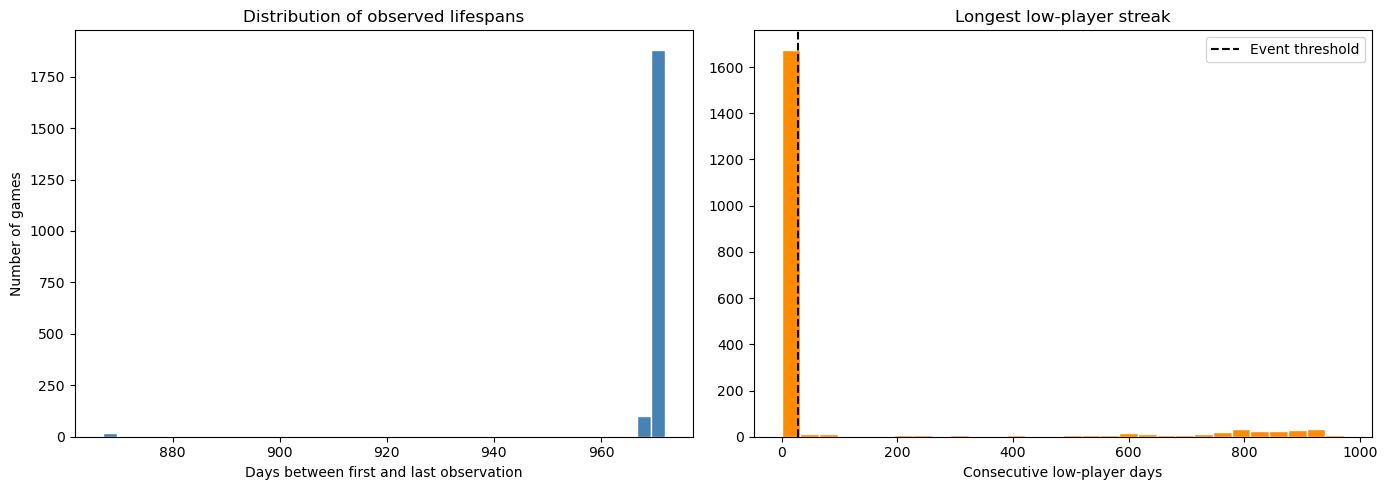

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(game_window["observed_lifespan_days"].dropna(), bins=40, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of observed lifespans")
axes[0].set_xlabel("Days between first and last observation")
axes[0].set_ylabel("Number of games")
axes[1].hist(game_window["max_low_streak_days"].dropna(), bins=30, color="darkorange", edgecolor="white")
axes[1].axvline(LOW_PLAYER_DAYS_REQUIRED, color="black", linestyle="--", label="Event threshold")
axes[1].set_title("Longest low-player streak")
axes[1].set_xlabel("Consecutive low-player days")
axes[1].legend()
plt.tight_layout()

## 3. Build early Steam and Twitch features

Features are calculated from the first 90 observed days for each game. The prediction target uses days 180-365, with at least 150 observed days required. This creates a forward-looking experiment: early signals predict later Steam retention.

In [27]:
panel["days_from_first_observation"] = (
    panel["date"] - panel.groupby("appid")["date"].transform("min")
).dt.days
early_panel = panel[panel["days_from_first_observation"].between(0, FEATURE_WINDOW_DAYS - 1)].copy()

early_features = early_panel.groupby("appid", as_index=False).agg(
    early_mean_players=("mean_player_count", "mean"),
    early_median_players=("median_player_count", "mean"),
    early_peak_players=("max_player_count", "max"),
    early_player_volatility=("mean_player_count", "std"),
    early_observation_days=("date", "nunique"),
    early_growth_log_players=("log_mean_player_count", lambda values: values.iloc[-1] - values.iloc[0])
)

twitch = pd.read_csv(TWITCH_PATH, parse_dates=["month"])
twitch["appid"] = pd.to_numeric(twitch["appid"], errors="coerce").astype("Int64")
first_dates = game_window[["appid", "first_observed"]].copy()
twitch = twitch.merge(first_dates, on="appid", how="inner")
twitch["months_from_first_observation"] = (
    (twitch["month"].dt.to_period("M") - twitch["first_observed"].dt.to_period("M")).apply(lambda value: value.n)
)
early_twitch = twitch[twitch["months_from_first_observation"].between(0, 2)].copy()

twitch_features = early_twitch.groupby("appid", as_index=False).agg(
    early_avg_viewers=("avgviewers", "mean"),
    early_peak_viewers=("maxviewers", "max"),
    early_view_minutes=("viewminutes", "sum"),
    early_avg_channels=("avgchannels", "mean"),
    early_unique_channels=("uniquechannels", "sum"),
    early_twitch_months=("month", "nunique")
)

print(f"Games with early Steam features: {len(early_features):,}")
print(f"Games with early Twitch features: {len(twitch_features):,}")

Games with early Steam features: 1,998
Games with early Twitch features: 850


In [28]:
metadata = pd.read_csv(DATA_DIR / "applicationInformation.csv", encoding="cp1252", low_memory=False)
metadata["appid"] = pd.to_numeric(metadata["appid"], errors="coerce").astype("Int64")
metadata["releasedate"] = pd.to_datetime(metadata["releasedate"], errors="coerce", dayfirst=True)
metadata["freetoplay"] = pd.to_numeric(metadata["freetoplay"], errors="coerce")
metadata = metadata[["appid", "type", "name", "releasedate", "freetoplay"]].drop_duplicates("appid")

def read_multi(filename, value_name):
    path = DATA_DIR / filename
    rows = []
    with path.open(encoding="cp1252") as file:
        for line in file:
            values = [value.strip() for value in line.rstrip("\r\n").split(",") if value.strip()]
            if values:
                rows.extend((int(values[0]), value) for value in values[1:])
    return pd.DataFrame(rows, columns=["appid", value_name])

genres = read_multi("applicationGenres.csv", "genre")
tags = read_multi("applicationTags.csv", "tag")
genre_features = genres.groupby("appid")["genre"].agg(lambda values: " | ".join(sorted(set(values)))).rename("genres")
tag_features = tags.groupby("appid")["tag"].agg(lambda values: " | ".join(sorted(set(values)))).rename("tags")

features = (
    game_window.merge(metadata, on="appid", how="left")
    .merge(early_features, on="appid", how="left")
    .merge(twitch_features, on="appid", how="left")
    .merge(genre_features, on="appid", how="left")
    .merge(tag_features, on="appid", how="left")
)
features["game_age_at_first_observation_years"] = (
    (features["first_observed"] - features["releasedate"]).dt.days / 365.25
)
features["freetoplay_status"] = features["freetoplay"].map({0: "paid", 1: "free_to_play"}).fillna("unknown")
features["primary_genre"] = features["genres"].fillna("Unknown").str.split(" \\| ").str[0]
features["retained_6_to_12m"] = features["retained_6_to_12m"].astype("Int64")

print(f"Final feature table: {features.shape}")
features.head()

Final feature table: (1998, 34)


,appid,first_observed,last_observed,observed_days,max_low_streak_days,max_player_count,observed_lifespan_days,inactivity_proxy,future_mean_players,future_median_players,...,early_peak_viewers,early_view_minutes,early_avg_channels,early_unique_channels,early_twitch_months,genres,tags,game_age_at_first_observation_years,freetoplay_status,primary_genre
0,10,2017-12-14,2020-08-12,973,0,31930.0,972,False,10408.696082,10128.836022,...,NaN,NaN,NaN,NaN,NaN,Action,1980s | 1990's | Action | Assassin | Classic |...,17.117043,paid,Action
1,20,2017-12-14,2020-08-12,972,0,193.0,972,False,57.902914,57.233871,...,NaN,NaN,NaN,NaN,NaN,Action,1990's | Action | Adventure | Class-Based | Cl...,18.704997,paid,Action
2,30,2017-12-14,2020-08-12,971,0,354.0,972,False,99.500584,103.948925,...,NaN,NaN,NaN,NaN,NaN,Action,Action | Class-Based | Classic | Co-op | FPS |...,14.622861,paid,Action
3,50,2017-12-14,2020-08-12,972,0,616.0,972,False,64.549984,63.645161,...,140465.0,7550400.0,0.000000,60.0,1.0,Action,1990's | Action | Adventure | Aliens | Atmosph...,18.119097,paid,Action
4,70,2017-12-14,2020-08-12,973,0,6022.0,972,False,397.353311,389.803763,...,11995.0,7067220.0,2.666667,2121.0,3.0,Action,1990's | Action | Adventure | Aliens | Atmosph...,19.099247,paid,Action


## 4. Compare groups

These comparisons provide interpretable results before machine learning. Games without a known genre are retained as `Unknown` for the numeric summaries.

In [17]:
genre_summary = (
    features.groupby("primary_genre")
    .agg(
        games=("appid", "nunique"),
        median_future_players=("future_mean_players", "median"),
        retention_rate=("retained_6_to_12m", "mean")
    )
    .query("games >= 10")
    .sort_values("retention_rate", ascending=False)
)

f2p_summary = features.groupby("freetoplay_status").agg(
    games=("appid", "nunique"),
    median_future_players=("future_mean_players", "median"),
    retention_rate=("retained_6_to_12m", "mean")
).sort_values("retention_rate", ascending=False)

display(f2p_summary.round(3))
display(genre_summary.head(15).round(3))

,games,median_future_players,retention_rate
freetoplay_status,,,
free_to_play,372,97.909,0.96
paid,1507,75.337,0.855
unknown,119,40.975,0.815


,games,median_future_players,retention_rate
primary_genre,,,
Strategy,92,123.109,1.0
Utilities,10,113.720,1.0
RPG,92,85.808,1.0
Free to Play,71,123.897,0.986
Simulation,92,124.656,0.978
Racing,34,81.349,0.941
Indie,150,77.162,0.887
Action,889,86.210,0.883
Early Access,21,66.780,0.857


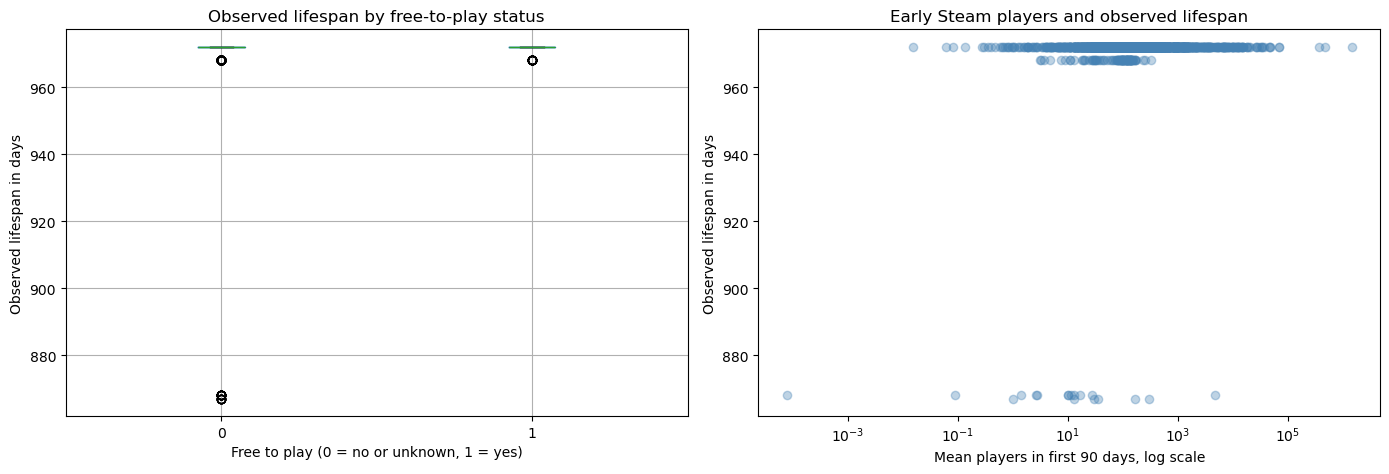

In [ ]:
plot_data = features.dropna(subset=["retained_6_to_12m"]).copy()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_data.boxplot(column="future_mean_players", by="freetoplay_status", ax=axes[0])
axes[0].set_title("Future Steam players by business model")
axes[0].set_xlabel("Free-to-play status")
axes[0].set_ylabel("Mean players in months 6-12")
axes[1].scatter(plot_data["early_mean_players"], plot_data["future_mean_players"], alpha=0.35, color="steelblue")
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_title("Early and future Steam players")
axes[1].set_xlabel("Mean players in first 90 days, log scale")
axes[1].set_ylabel("Mean players in months 6-12, log scale")
plt.suptitle("")
plt.tight_layout()

In [24]:
retention_sensitivity = pd.DataFrame({
    "threshold_players": [1, 5, 10, 25, 50],
    "retained_games": [
        features["future_mean_players"].ge(threshold).sum()
        for threshold in [1, 5, 10, 25, 50]
    ]
})
retention_sensitivity["retention_rate"] = (
    retention_sensitivity["retained_games"] / features["target_available"].sum()
)
display(retention_sensitivity.round(3))

,threshold_players,retained_games,retention_rate
0,1,1903,0.953
1,5,1797,0.900
2,10,1743,0.873
3,25,1570,0.786
4,50,1242,0.622


## 5. Machine-learning setup

The models use only games with at least 150 observed days in the future window and at least seven early Steam observations. Features come from the first 90 observed days; targets come from days 180-365. A chronological split tests whether the model generalizes from earlier-observed games to later-observed games.

In [29]:
numeric_features = [
    "game_age_at_first_observation_years",
    "early_mean_players", "early_median_players", "early_peak_players",
    "early_player_volatility", "early_growth_log_players",
    "early_avg_viewers", "early_peak_viewers", "early_view_minutes",
    "early_avg_channels", "early_unique_channels", "early_twitch_months"
]
categorical_features = ["type", "freetoplay_status", "primary_genre"]
model_data = features[features["target_available"]].copy()
model_data = model_data[model_data["early_observation_days"].fillna(0).ge(7)].copy()
model_data["future_log_players"] = np.log1p(model_data["future_mean_players"])

X = model_data[numeric_features + categorical_features]
y_regression = model_data["future_log_players"]
y_classification = model_data["retained_6_to_12m"].astype(int)

# Chronological split: earlier-observed games train the model; later-observed games test it.
split_date = model_data["first_observed"].quantile(0.75)
train_mask = model_data["first_observed"].le(split_date)
X_train = X.loc[train_mask]
X_test = X.loc[~train_mask]
y_train_reg = y_regression.loc[train_mask]
y_test_reg = y_regression.loc[~train_mask]
y_train_cls = y_classification.loc[train_mask]
y_test_cls = y_classification.loc[~train_mask]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_features),
        ("categorical", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_features)
    ]
)
print(f"Model games: {len(model_data):,}; train: {len(X_train):,}; test: {len(X_test):,}")
print(f"Chronological cutoff: {split_date.date()}")
print(f"Training retention rate: {y_train_cls.mean():.1%}; test retention rate: {y_test_cls.mean():.1%}")

Model games: 1,997; train: 1,880; test: 117
Chronological cutoff: 2017-12-14
Training retention rate: 87.9%; test retention rate: 76.9%


## 6. Predict future Steam players

A linear model gives a simple baseline. The random forest can capture nonlinear relationships, such as diminishing returns from very high early player counts. The regression target is log-transformed during training because player counts are strongly right-skewed.

In [30]:
regression_models = {
    "Linear regression": Pipeline([("prep", preprocessor), ("model", LinearRegression())]),
    "Random forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(n_estimators=300, min_samples_leaf=3, random_state=42, n_jobs=-1))
    ])
}

regression_results = []
y_test_players = np.expm1(y_test_reg)
for name, model in regression_models.items():
    model.fit(X_train, y_train_reg)
    predictions = np.maximum(0, np.expm1(model.predict(X_test)))
    regression_results.append({
        "model": name,
        "MAE_future_players": mean_absolute_error(y_test_players, predictions),
        "RMSE_future_players": mean_squared_error(y_test_players, predictions) ** 0.5,
        "R2_future_players": r2_score(y_test_players, predictions)
    })

regression_results = pd.DataFrame(regression_results).sort_values("MAE_future_players")
display(regression_results.round(2))

,model,MAE_future_players,RMSE_future_players,R2_future_players
1,Random forest,26.28,65.92,0.95
0,Linear regression,153.62,714.49,-5.24


In [31]:
# Test whether Twitch adds predictive value beyond Steam and metadata.
def build_preprocessor(numeric_columns, categorical_columns):
    return ColumnTransformer(
        transformers=[
            ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median"))]), numeric_columns),
            ("categorical", Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", OneHotEncoder(handle_unknown="ignore"))
            ]), categorical_columns)
        ]
    )

feature_sets = {
    "Metadata only": (["game_age_at_first_observation_years"], ["type", "freetoplay_status", "primary_genre"]),
    "Twitch + metadata": (["early_avg_viewers", "early_peak_viewers", "early_view_minutes", "early_avg_channels", "early_unique_channels", "early_twitch_months"], ["type", "freetoplay_status", "primary_genre"]),
    "Metadata + Steam": (numeric_features[:6], ["type", "freetoplay_status", "primary_genre"]),
    "Metadata + Steam + Twitch": (numeric_features, ["type", "freetoplay_status", "primary_genre"])
}

ablation_results = []
for name, (numeric_columns, categorical_columns) in feature_sets.items():
    columns = numeric_columns + categorical_columns
    subset_train = X_train[columns]
    subset_test = X_test[columns]
    model = Pipeline([
        ("prep", build_preprocessor(numeric_columns, categorical_columns)),
        ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight="balanced", random_state=42, n_jobs=-1))
    ])
    model.fit(subset_train, y_train_cls)
    predictions = model.predict(subset_test)
    probabilities = model.predict_proba(subset_test)[:, 1]
    ablation_results.append({
        "feature_set": name,
        "balanced_accuracy": balanced_accuracy_score(y_test_cls, predictions),
        "roc_auc": roc_auc_score(y_test_cls, probabilities)
    })

ablation_results = pd.DataFrame(ablation_results).sort_values("roc_auc", ascending=False)
display(ablation_results.round(3))

,feature_set,balanced_accuracy,roc_auc
3,Metadata + Steam + Twitch,0.878,0.958
2,Metadata + Steam,0.870,0.951
1,Twitch + metadata,0.756,0.803
0,Metadata only,0.648,0.706


## 7. Classify retained and non-retained games

A game is classified as retained when its mean Steam player count during months 6-12 is at least 10. Accuracy alone is insufficient if the classes are imbalanced, so balanced accuracy and ROC-AUC are also reported. The ablation table tests whether Twitch improves prediction.

In [32]:
classification_models = {
    "Logistic regression": Pipeline([
        ("prep", preprocessor),
        ("scale", StandardScaler(with_mean=False)),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ]),
    "Random forest": Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight="balanced", random_state=42, n_jobs=-1))
    ])
}

classification_results = [{
    "model": "Always retained baseline",
    "accuracy": y_test_cls.mean(),
    "balanced_accuracy": balanced_accuracy_score(y_test_cls, np.ones(len(y_test_cls))),
    "roc_auc": 0.5
}]
for name, model in classification_models.items():
    model.fit(X_train, y_train_cls)
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]
    classification_results.append({
        "model": name,
        "accuracy": accuracy_score(y_test_cls, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_test_cls, predictions),
        "roc_auc": roc_auc_score(y_test_cls, probabilities)
    })
    print(f"\n{name}")
    print(classification_report(y_test_cls, predictions, target_names=["not retained", "retained"]))

classification_results = pd.DataFrame(classification_results).sort_values("roc_auc", ascending=False)
display(classification_results.round(3))


Logistic regression
              precision    recall  f1-score   support

not retained       0.47      0.63      0.54        27
    retained       0.88      0.79      0.83        90

    accuracy                           0.75       117
   macro avg       0.67      0.71      0.69       117
weighted avg       0.78      0.75      0.76       117


Random forest
              precision    recall  f1-score   support

not retained       0.67      0.89      0.76        27
    retained       0.96      0.87      0.91        90

    accuracy                           0.87       117
   macro avg       0.81      0.88      0.84       117
weighted avg       0.89      0.87      0.88       117



,model,accuracy,balanced_accuracy,roc_auc
2,Random forest,0.872,0.878,0.958
1,Logistic regression,0.752,0.709,0.791
0,Always retained baseline,0.769,0.500,0.500


In [33]:
# Actionable output: a retention-risk table for later-observed games.
full_model = classification_models["Random forest"]
test_probabilities = full_model.predict_proba(X_test)[:, 1]
risk_table = model_data.loc[X_test.index, ["appid", "name", "first_observed", "early_mean_players", "early_median_players"]].copy()
risk_table["retention_probability"] = test_probabilities
risk_table["risk_category"] = pd.cut(
    risk_table["retention_probability"],
    bins=[-np.inf, 0.50, 0.75, np.inf],
    labels=["high risk", "medium risk", "low risk"]
)
risk_table = risk_table.sort_values("retention_probability")
display(risk_table.head(10).round(3))
display(risk_table.tail(10).sort_values("retention_probability", ascending=False).round(3))

,appid,name,first_observed,early_mean_players,early_median_players,retention_probability,risk_category
1770,575840,NeverEnd,2017-12-18,8.721,7.202,0.011,high risk
1786,581030,The Last Hope Trump vs Mafia,2017-12-18,12.757,5.843,0.012,high risk
1008,338530,Trouble In The Manor,2017-12-18,10.953,7.382,0.023,high risk
1243,400740,VERGE:Lost chapter,2017-12-18,3.256,2.685,0.034,high risk
1598,507390,Gone In November,2017-12-18,7.494,5.983,0.036,high risk
1504,469730,Super Mega Neo Pug,2017-12-18,18.426,12.067,0.048,high risk
1565,495780,Hexoscope,2017-12-18,3.606,2.933,0.050,high risk
696,262150,Vanguard Princess,2017-12-18,3.115,2.927,0.053,high risk
1890,623550,Timen runner,2017-12-18,17.826,12.961,0.054,high risk
1570,496680,SweatShop,2017-12-18,19.972,15.371,0.055,high risk


,appid,name,first_observed,early_mean_players,early_median_players,retention_probability,risk_category
242,40800,Super Meat Boy,2017-12-18,134.769,133.382,1.000,low risk
401,209870,Blacklight: Retribution,2017-12-18,140.014,140.236,0.999,low risk
1276,410380,HEX: Shards of Fate,2017-12-18,120.236,119.022,0.999,low risk
666,254200,FortressCraft Evolved,2017-12-18,167.368,167.157,0.998,low risk
126,15100,Assassin's Creed,2017-12-18,90.996,88.404,0.998,low risk
269,47780,Dead Space 2,2017-12-18,142.819,140.112,0.998,low risk
1648,527230,For The King,2017-12-18,249.383,252.573,0.998,low risk
855,302510,Ryse: Son of Rome,2017-12-18,99.113,96.281,0.998,low risk
221,35700,Trine,2017-12-18,73.425,70.112,0.998,low risk
772,285160,LEGO® The Hobbit™,2017-12-18,106.585,100.258,0.998,low risk


## 8. Inspect feature importance

Feature importance indicates which variables help prediction; it does not establish causality. The permutation approach measures the change in test-set performance when one column is shuffled.

,feature,performance_loss_when_shuffled
2,early_median_players,1.030
1,early_mean_players,0.034
4,early_player_volatility,0.032
13,freetoplay_status,0.025
0,game_age_at_first_observation_years,0.023
5,early_growth_log_players,0.019
3,early_peak_players,0.017
7,early_peak_viewers,0.002
11,early_twitch_months,0.000
14,primary_genre,0.000


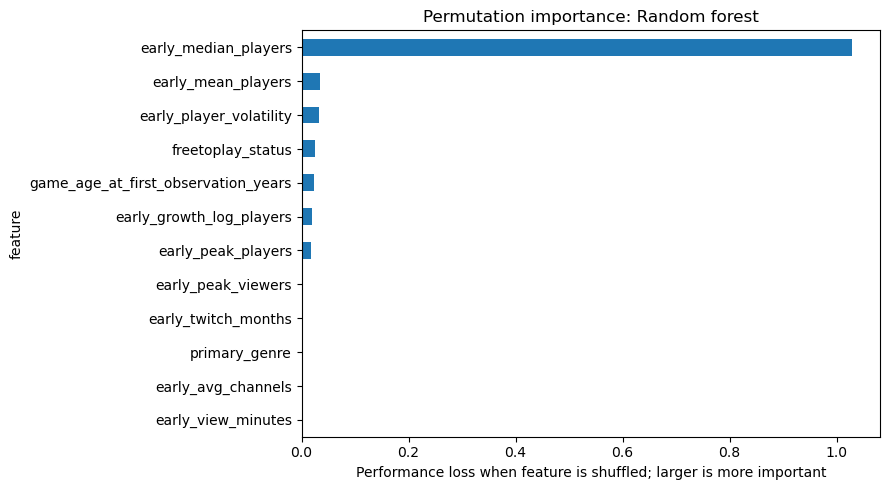

In [34]:
from sklearn.inspection import permutation_importance

best_regression_name = regression_results.iloc[0]["model"]
best_regression_model = regression_models[best_regression_name]
permutation = permutation_importance(
    best_regression_model, X_test, y_test_reg, scoring="neg_mean_absolute_error",
    n_repeats=10, random_state=42, n_jobs=-1
)
importance = pd.DataFrame({
    "feature": X_test.columns,
    "performance_loss_when_shuffled": permutation.importances_mean
}).sort_values("performance_loss_when_shuffled", ascending=False)
display(importance.round(3))

importance.sort_values("performance_loss_when_shuffled").tail(12).plot(
    x="feature", y="performance_loss_when_shuffled", kind="barh", figsize=(9, 5),
    title=f"Permutation importance: {best_regression_name}", legend=False
)
plt.xlabel("Performance loss when feature is shuffled; larger is more important")
plt.tight_layout()

## 9. Conclusions and limitations

Use the model tables and plots above to answer the research question. Report the retention definition, target coverage, chronological split, class balance, balanced accuracy and ROC-AUC, and whether Twitch improves prediction beyond metadata and early Steam activity. The actionable risk table translates probabilities into a form that a publisher or developer could review.

**Limitations:**

- The threshold of 10 players and 150-day coverage requirement are operational choices. Repeat the analysis with thresholds such as 1, 5, 25, and 50 players.
- Twitch coverage is incomplete and may be affected by game popularity, so missing Twitch values are not necessarily zero.
- The data is observational. Predictive importance and associations should not be interpreted as causal effects.
- Developers, franchises, and release cohorts may create dependencies between games.
- The chronological test set contains fewer games than the training set, so metrics should be reported with uncertainty in a final study.
- The original observed-lifespan target is highly compressed because all games share the same administrative collection end date; it is included only for descriptive context.

The final presentation should compare the model with the always-retained baseline and explain that the strongest signal is early Steam player behavior. Twitch is useful when Steam activity is unavailable, but its incremental value after early Steam activity should be judged from the ablation table.